# Part 4 — Vector Databases: Embeddings & Semantic Similarity


## 1. Install dependencies

In [7]:
!pip install -q sentence-transformers scikit-learn seaborn matplotlib numpy


## 2. Imports

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully.')


All libraries imported successfully.


## 3. Define 10 sentences across 3 topics

In [9]:
sentences = [
    # ── Cricket (4 sentences) ──────────────────────────────────
    "The batsman hit a stunning six over the boundary.",
    "India won the test match by an innings and fifty runs.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "The fielder took a brilliant catch at deep mid-wicket.",

    # ── Cooking (3 sentences) ──────────────────────────────────
    "Sauté the onions in olive oil until they turn golden brown.",
    "Marinate the chicken in yogurt and spices for at least two hours.",
    "Fold the egg whites gently into the batter to keep it light.",

    # ── Cybersecurity (3 sentences) ────────────────────────────
    "The hacker exploited a SQL injection vulnerability in the login form.",
    "Two-factor authentication significantly reduces the risk of account takeover.",
    "Always patch your systems promptly to close known security vulnerabilities.",
]

topic_labels = ['Cricket']*4 + ['Cooking']*3 + ['Cybersecurity']*3

print('Sentences (10 total across 3 topics):')
print('-' * 52)
for i, (s, t) in enumerate(zip(sentences, topic_labels)):
    print(f'  [{i:2d}] [{t:13s}]  {s}')


Sentences (10 total across 3 topics):
----------------------------------------------------
  [ 0] [Cricket      ]  The batsman hit a stunning six over the boundary.
  [ 1] [Cricket      ]  India won the test match by an innings and fifty runs.
  [ 2] [Cricket      ]  The spinner bowled a perfect googly to dismiss the opener.
  [ 3] [Cricket      ]  The fielder took a brilliant catch at deep mid-wicket.
  [ 4] [Cooking      ]  Sauté the onions in olive oil until they turn golden brown.
  [ 5] [Cooking      ]  Marinate the chicken in yogurt and spices for at least two hours.
  [ 6] [Cooking      ]  Fold the egg whites gently into the batter to keep it light.
  [ 7] [Cybersecurity]  The hacker exploited a SQL injection vulnerability in the login form.
  [ 8] [Cybersecurity]  Two-factor authentication significantly reduces the risk of account takeover.
  [ 9] [Cybersecurity]  Always patch your systems promptly to close known security vulnerabilities.


## 4. Generate embeddings using `all-MiniLM-L6-v2`

In [10]:
print('Loading model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding 10 sentences...')
embeddings = model.encode(sentences, show_progress_bar=False)

print(f'Embedding shape : {embeddings.shape}  (10 sentences × 384 dims)')
print(f'Embedding dtype : {embeddings.dtype}')


Loading model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 10 sentences...
Embedding shape : (10, 384)  (10 sentences × 384 dims)
Embedding dtype : float32


## 5. Compute 10×10 cosine similarity matrix and display as heatmap

Dashed lines separate the three topic blocks. Warm colours = high similarity, cool = low.


Cosine Similarity Matrix (10x10):
        S0   S1   S2   S3   S4   S5   S6   S7   S8   S9 
  S0 | 1.000 0.447 0.395 0.558 0.001 -0.009 0.076 0.112 -0.025 0.000
  S1 | 0.447 1.000 0.330 0.464 0.023 -0.024 0.128 0.066 -0.051 -0.024
  S2 | 0.395 0.330 1.000 0.496 0.118 0.062 0.156 0.132 -0.022 0.058
  S3 | 0.558 0.464 0.496 1.000 0.046 0.074 0.133 0.124 -0.007 0.006
  S4 | 0.001 0.023 0.118 0.046 1.000 0.288 0.405 -0.012 -0.137 0.136
  S5 | -0.009 -0.024 0.062 0.074 0.288 1.000 0.236 0.007 -0.077 0.114
  S6 | 0.076 0.128 0.156 0.133 0.405 0.236 1.000 0.003 -0.021 -0.003
  S7 | 0.112 0.066 0.132 0.124 -0.012 0.007 0.003 1.000 0.316 0.298
  S8 | -0.025 -0.051 -0.022 -0.007 -0.137 -0.077 -0.021 0.316 1.000 0.106
  S9 | 0.000 -0.024 0.058 0.006 0.136 0.114 -0.003 0.298 0.106 1.000


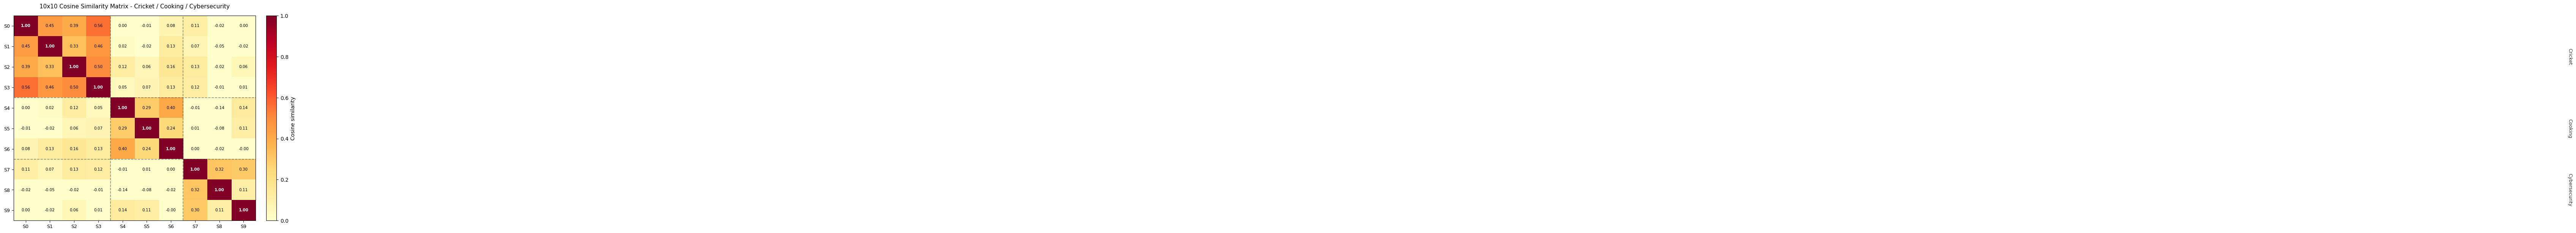

Heatmap saved as heatmap.png


In [11]:
# ── Compute pairwise cosine similarities ────────────────────
sim_matrix = cosine_similarity(embeddings)   # shape (10, 10)

# ── Print numeric matrix ─────────────────────────────────────
lbl = [f'S{i}' for i in range(10)]
print('Cosine Similarity Matrix (10x10):')
print('      ' + ''.join(f'  {l:2s} ' for l in lbl))
for i, row in enumerate(sim_matrix):
    print(f'  {lbl[i]} |' + ''.join(f' {v:.3f}' for v in row))

# ── Heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(lbl, fontsize=9)
ax.set_yticklabels(lbl, fontsize=9)

for i in range(10):
    for j in range(10):
        v = sim_matrix[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7.5, color='white' if v > 0.6 else 'black',
                fontweight='bold' if i == j else 'normal')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity', fontsize=10)
ax.set_title('10x10 Cosine Similarity Matrix - Cricket / Cooking / Cybersecurity',
             fontsize=11, pad=14)

for pos in [3.5, 6.5]:
    ax.axhline(pos, color='#444', lw=1.2, ls='--', alpha=0.6)
    ax.axvline(pos, color='#444', lw=1.2, ls='--', alpha=0.6)

for ltext, ypos in [('Cricket', 1.5), ('Cooking', 5.0), ('Cybersecurity', 8.0)]:
    ax.text(10.55, ypos, ltext, va='center', fontsize=9,
            rotation=270, transform=ax.get_yaxis_transform(), color='#333')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Heatmap saved as heatmap.png')


## 6. Query: find top-2 most similar sentences

Query sentence: **"The bowler took three wickets in one over"**


In [12]:
query = "The bowler took three wickets in one over"

query_vec = model.encode([query])
q_sims    = cosine_similarity(query_vec, embeddings)[0]
top2_idx  = np.argsort(q_sims)[::-1][:2]

print(f'Query: "{query}"')
print('-' * 60)
print('Top 2 most similar sentences:\n')
for rank, idx in enumerate(top2_idx, 1):
    print(f'  Rank {rank} | Similarity: {q_sims[idx]:.4f}')
    print(f'  Topic    : {topic_labels[idx]}')
    print(f'  Sentence : "{sentences[idx]}"')
    print()


Query: "The bowler took three wickets in one over"
------------------------------------------------------------
Top 2 most similar sentences:

  Rank 1 | Similarity: 0.5592
  Topic    : Cricket
  Sentence : "India won the test match by an innings and fifty runs."

  Rank 2 | Similarity: 0.5569
  Topic    : Cricket
  Sentence : "The batsman hit a stunning six over the boundary."

